# Academic Impacts of AI

Justin Southworth

# Business Problem
Creating informed educational legislation requires a clear understanding of how emerging technologies influence student outcomes. 

Looking at a representative population of 8,000 students over the course of a single school year, how does the use of AI—and the manner of that use—specifically affect Final Scores and Improvement Rates?


# About This Data
The data is categorized into four key areas:

**AI Interaction Metrics:** Detailed tracking of AI usage, including specific tools (ChatGPT, Gemini, Copilot), daily usage time (minutes), purpose of usage (e.g., Doubt Solving, Exam Prep), and a unique AI Dependency Score.

**Academic Performance:** Core metrics such as Final Score, Last Exam Score, Assignment Scores, and Concept Understanding Score.

**Study Habits & Lifestyle:** Insight into student life outside the classroom, including Sleep Hours, Social Media Consumption, Study Consistency, and Attendance.

**Demographics:** Standard identifiers like Age, Gender, and Grade Level (High School to University).

# Key Columns
**AI_Dependency_Score:** A derived metric indicating how heavily a student relies on AI for coursework.

**AI_Ethics_Score:** A measure of the student's adherence to academic integrity while using AI.

**Concept_Understanding_Score:** Assessment of the student's grasp of core subjects, independent of AI aid.

**Performance_Category:** Classification of the student (Low, Medium, High) based on overall scores.

# Setup, Data Loading, and Data Checking

In [472]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
import scipy.stats as stats

In [473]:
# Set the default style for seaborn plots to 'whitegrid'
sns.set_style('whitegrid')
# Update matplotlib parameters for transparent backgrounds
plt.rcParams.update({
    # Make the figure background transparent when saving
    "savefig.transparent": True,
    # Make the figure background transparent on screen
    "figure.facecolor": "none",
    # Make the plot area (axes) background transparent
    "axes.facecolor": "none",
})

In [474]:
stud = pd.read_csv('content/ai_impact_student_performance_dataset.csv')

In [475]:
stud.head()

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


In [476]:
stud.tail()

,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
7995,7996,23,Male,3rd Year,3.0,0,178,Gemini,NaN,6,...,5,8.1,19.2,8.3,1.9,1.0,10,49.7,1,Low
7996,7997,21,Other,1st Year,3.3,0,63,Claude,Exam Prep,10,...,6,5.7,3.0,5.0,1.3,2.9,5,58.4,1,Medium
7997,7998,24,Male,3rd Year,1.6,0,113,ChatGPT,Coding,5,...,6,4.5,-18.0,5.0,3.5,0.1,9,69.1,1,Medium
7998,7999,22,Female,2nd Year,5.5,0,21,Copilot,Coding,5,...,8,3.4,-19.1,4.7,5.9,0.4,7,49.2,1,Low
7999,8000,15,Male,12th,4.6,0,42,NaN,NaN,9,...,6,9.7,-4.9,9.0,2.9,2.1,5,69.7,1,Medium


In [477]:
stud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       8000 non-null   int64  
 1   age                              8000 non-null   int64  
 2   gender                           8000 non-null   object 
 3   grade_level                      8000 non-null   object 
 4   study_hours_per_day              8000 non-null   float64
 5   uses_ai                          8000 non-null   int64  
 6   ai_usage_time_minutes            8000 non-null   int64  
 7   ai_tools_used                    6638 non-null   object 
 8   ai_usage_purpose                 6654 non-null   object 
 9   ai_dependency_score              8000 non-null   int64  
 10  ai_generated_content_percentage  8000 non-null   int64  
 11  ai_prompts_per_week              8000 non-null   int64  
 12  ai_ethics_score     

# Data Cleaning

In [478]:
# Fill missing values for AI related columns
stud.loc[(stud['uses_ai'] == 0) & (stud['ai_tools_used'].isnull()), 'ai_tools_used'] = 'None'
stud.loc[(stud['uses_ai'] == 1) & (stud['ai_tools_used'].isnull()), 'ai_tools_used'] = 'Unknown'

stud.loc[(stud['uses_ai'] == 0) & (stud['ai_usage_purpose'].isnull()), 'ai_usage_purpose'] = 'None'
stud.loc[(stud['uses_ai'] == 1) & (stud['ai_usage_purpose'].isnull()), 'ai_usage_purpose'] = 'Unknown'

In [479]:
stud.isnull().sum()

student_id                         0
age                                0
gender                             0
grade_level                        0
study_hours_per_day                0
uses_ai                            0
ai_usage_time_minutes              0
ai_tools_used                      0
ai_usage_purpose                   0
ai_dependency_score                0
ai_generated_content_percentage    0
ai_prompts_per_week                0
ai_ethics_score                    0
last_exam_score                    0
assignment_scores_avg              0
attendance_percentage              0
concept_understanding_score        0
study_consistency_index            0
improvement_rate                   0
sleep_hours                        0
social_media_hours                 0
tutoring_hours                     0
class_participation_score          0
final_score                        0
passed                             0
performance_category               0
dtype: int64

In [480]:
#Convert Performance Category
stud['performance_category'] = pd.Categorical(stud['performance_category'], categories=['Low', 'Medium', 'High'], ordered=True)

In [481]:
stud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   student_id                       8000 non-null   int64   
 1   age                              8000 non-null   int64   
 2   gender                           8000 non-null   object  
 3   grade_level                      8000 non-null   object  
 4   study_hours_per_day              8000 non-null   float64 
 5   uses_ai                          8000 non-null   int64   
 6   ai_usage_time_minutes            8000 non-null   int64   
 7   ai_tools_used                    8000 non-null   object  
 8   ai_usage_purpose                 8000 non-null   object  
 9   ai_dependency_score              8000 non-null   int64   
 10  ai_generated_content_percentage  8000 non-null   int64   
 11  ai_prompts_per_week              8000 non-null   int64   
 12  ai_eth

Note: The following 3 cells require the user_class category to be instantiated in the feature engineering section.

In [482]:
#pd.crosstab(stud['user_class'], stud['gender'])

In [483]:
#pd.crosstab(stud['user_class'], stud['age'])

In [484]:
#pd.crosstab(stud['user_class'], stud['grade_level'])

In [485]:
#Drop irrelevant columns
stud = stud.drop(['student_id',
                  'age',
                  'gender',
                  'grade_level',
                  'sleep_hours',
                  'social_media_hours',
                  'passed',
                  'tutoring_hours',
                  'attendance_percentage',
                  'class_participation_score'
                 ], axis=1)

In [486]:
stud.head()

,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,assignment_scores_avg,concept_understanding_score,study_consistency_index,improvement_rate,final_score,performance_category
0,2.5,1,170,Unknown,Exam Prep,10,29,56,5,29,40.9,4,9.0,8.1,36.8,Low
1,3.4,1,123,Unknown,Notes,4,14,65,1,60,87.2,8,8.5,13.8,65.5,Medium
2,0.8,0,35,Copilot,Doubt Solving,8,82,8,5,98,77.1,7,2.1,39.1,66.3,Medium
3,4.4,0,45,ChatGPT+Gemini,Notes,3,74,106,10,67,86.4,5,6.7,25.2,69.5,Medium
4,3.5,1,21,ChatGPT+Gemini,Coding,2,83,7,10,40,69.4,5,5.4,2.7,49.7,Low


In [487]:
stud.describe(include ='all')

,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,assignment_scores_avg,concept_understanding_score,study_consistency_index,improvement_rate,final_score,performance_category
count,8000.000000,8000.000000,8000.000000,8000,8000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000
unique,NaN,NaN,NaN,7,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,ChatGPT+Gemini,Exam Prep,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium
freq,NaN,NaN,NaN,1399,1368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4705
mean,3.286938,0.641000,88.989875,NaN,NaN,5.515125,50.057500,59.359500,5.472375,59.501250,65.108400,5.484750,5.516450,10.127325,56.811988,NaN
std,1.582171,0.479737,52.184077,NaN,NaN,2.883064,29.440109,34.869496,2.872067,23.161888,20.022293,2.898546,2.586377,17.479288,13.455724,NaN
min,0.500000,0.000000,0.000000,NaN,NaN,1.000000,0.000000,0.000000,1.000000,20.000000,30.000000,1.000000,1.000000,-20.000000,12.700000,NaN
25%,1.900000,0.000000,43.000000,NaN,NaN,3.000000,25.000000,29.000000,3.000000,39.750000,47.900000,3.000000,3.200000,-5.000000,47.300000,NaN
50%,3.300000,1.000000,89.000000,NaN,NaN,6.000000,50.000000,59.000000,6.000000,59.000000,65.100000,5.000000,5.500000,10.150000,56.900000,NaN
75%,4.600000,1.000000,134.000000,NaN,NaN,8.000000,76.000000,90.000000,8.000000,80.000000,82.300000,8.000000,7.800000,25.500000,66.200000,NaN


# Feature Engineering

In [488]:
#AI metrics dataframe
ai_metrics = stud[['uses_ai','ai_usage_time_minutes', 'ai_tools_used', 'ai_usage_purpose', 'ai_dependency_score', 'ai_generated_content_percentage', 'ai_prompts_per_week', 'ai_ethics_score']]

In [489]:
ai_metrics

,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score
0,1,170,Unknown,Exam Prep,10,29,56,5
1,1,123,Unknown,Notes,4,14,65,1
2,0,35,Copilot,Doubt Solving,8,82,8,5
3,0,45,ChatGPT+Gemini,Notes,3,74,106,10
4,1,21,ChatGPT+Gemini,Coding,2,83,7,10
...,...,...,...,...,...,...,...,...
7995,0,178,Gemini,None,6,61,112,7
7996,0,63,Claude,Exam Prep,10,83,8,2
7997,0,113,ChatGPT,Coding,5,23,100,8
7998,0,21,Copilot,Coding,5,68,63,7


In [490]:
ai_metrics.describe(percentiles=(.10, .25, .33, .50, .66, .75, .90))

,uses_ai,ai_usage_time_minutes,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,0.641000,88.989875,5.515125,50.057500,59.359500,5.472375
std,0.479737,52.184077,2.883064,29.440109,34.869496,2.872067
min,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
10%,0.000000,17.000000,1.000000,9.000000,11.000000,1.000000
25%,0.000000,43.000000,3.000000,25.000000,29.000000,3.000000
33%,0.000000,58.000000,4.000000,33.000000,39.000000,4.000000
50%,1.000000,89.000000,6.000000,50.000000,59.000000,6.000000
66%,1.000000,118.000000,7.000000,66.000000,79.000000,7.000000
75%,1.000000,134.000000,8.000000,76.000000,90.000000,8.000000


In [491]:
# Calculate the 33rd percentile (first tercile) of AI usage time in minutes
qautm1 = ai_metrics['ai_usage_time_minutes'].quantile(.33)
# Count how many records have AI usage time less than or equal to the first tercile
print(ai_metrics[(ai_metrics['ai_usage_time_minutes']<= qautm1)].shape[0])

# Calculate the 33rd percentile of AI generated content percentage
qagcp1 = ai_metrics['ai_generated_content_percentage'].quantile(.33)
# Count how many records have AI generated content percentage less than or equal to the first tercile
print(ai_metrics[(ai_metrics['ai_generated_content_percentage']<= qagcp1)].shape[0])

# Calculate the 33rd percentile of AI prompts per week
qappw1 = ai_metrics['ai_prompts_per_week'].quantile(.33)
# Count how many records have AI prompts per week less than or equal to the first tercile
print(ai_metrics[(ai_metrics['ai_prompts_per_week']<= qappw1)].shape[0])

# Calculate the 33rd percentile of AI ethics score
qaes1 = ai_metrics['ai_ethics_score'].quantile(.33)
# Count how many records have AI ethics score less than or equal to the first tercile
print(ai_metrics[(ai_metrics['ai_ethics_score']<= qaes1)].shape[0])

2662
2710
2700
3199


In [492]:
# Calculate the 66th percentile of AI usage time in minutes
qautm2 = ai_metrics['ai_usage_time_minutes'].quantile(.66)
# Count how many records have AI usage time less than or equal to the 66th percentile
print(ai_metrics[(ai_metrics['ai_usage_time_minutes']<= qautm2)].shape[0])

# Calculate the 66th percentile of AI generated content percentage
qagcp2 = ai_metrics['ai_generated_content_percentage'].quantile(.66)
# Count how many records have AI generated content percentage less than or equal to the 66th percentile
print(ai_metrics[(ai_metrics['ai_generated_content_percentage']<= qagcp2)].shape[0])

# Calculate the 66th percentile of AI prompts per week
qappw2 = ai_metrics['ai_prompts_per_week'].quantile(.66)
# Count how many records have AI prompts per week less than or equal to the 66th percentile
print(ai_metrics[(ai_metrics['ai_prompts_per_week']<= qappw2)].shape[0])

# Calculate the 66th percentile of AI ethics score
qaes2 = ai_metrics['ai_ethics_score'].quantile(.66)
# Count how many records have AI ethics score less than or equal to the 66th percentile
print(ai_metrics[(ai_metrics['ai_ethics_score']<= qaes2)].shape[0])

5314
5288
5310
5650


In [493]:
#Performance Metrics
perf_metrics = stud[['last_exam_score', 'assignment_scores_avg', 'concept_understanding_score', 'study_consistency_index', 'improvement_rate', 'final_score', 'performance_category']]

In [494]:
perf_metrics

,last_exam_score,assignment_scores_avg,concept_understanding_score,study_consistency_index,improvement_rate,final_score,performance_category
0,29,40.9,4,9.0,8.1,36.8,Low
1,60,87.2,8,8.5,13.8,65.5,Medium
2,98,77.1,7,2.1,39.1,66.3,Medium
3,67,86.4,5,6.7,25.2,69.5,Medium
4,40,69.4,5,5.4,2.7,49.7,Low
...,...,...,...,...,...,...,...
7995,32,73.1,5,8.1,19.2,49.7,Low
7996,74,58.8,6,5.7,3.0,58.4,Medium
7997,87,42.5,6,4.5,-18.0,69.1,Medium
7998,28,73.8,8,3.4,-19.1,49.2,Low


In [495]:
perf_metrics.describe()

,last_exam_score,assignment_scores_avg,concept_understanding_score,study_consistency_index,improvement_rate,final_score
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,59.501250,65.108400,5.484750,5.516450,10.127325,56.811988
std,23.161888,20.022293,2.898546,2.586377,17.479288,13.455724
min,20.000000,30.000000,1.000000,1.000000,-20.000000,12.700000
25%,39.750000,47.900000,3.000000,3.200000,-5.000000,47.300000
50%,59.000000,65.100000,5.000000,5.500000,10.150000,56.900000
75%,80.000000,82.300000,8.000000,7.800000,25.500000,66.200000
max,99.000000,100.000000,10.000000,10.000000,40.000000,95.800000


In [496]:
perf_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   last_exam_score              8000 non-null   int64   
 1   assignment_scores_avg        8000 non-null   float64 
 2   concept_understanding_score  8000 non-null   int64   
 3   study_consistency_index      8000 non-null   float64 
 4   improvement_rate             8000 non-null   float64 
 5   final_score                  8000 non-null   float64 
 6   performance_category         8000 non-null   category
dtypes: category(1), float64(4), int64(2)
memory usage: 383.1 KB


In [497]:
# Filter for self-reported non-users
stated_non_users = stud[stud['uses_ai'] == 0]

In [498]:
# Check for evidence of usage in other columns
# We'll consider a student a "Shadow User" if they have significant non-zero values in usage metrics
# or specified tools/purposes.
# Let's check the distributions first to set a threshold if needed, or just use > 0.
# In the head(), row 2 has uses_ai=0 but ai_usage_time=35.

# Define Shadow Users
# Condition: uses_ai == 0 AND (ai_usage_time_minutes > 0 OR ai_prompts_per_week > 0 OR ai_generated_content > 0)
# We need to be careful with "0" vs "Null".
# Based on previous info(), these columns are int/float, so likely 0.

shadow_condition = (
    (stud['uses_ai'] == 0) & 
    (
        (stud['ai_usage_time_minutes'] > 0) | 
        (stud['ai_prompts_per_week'] > 0) |
        (stud['ai_generated_content_percentage'] > 0) |
        (stud['ai_tools_used'].notnull())
    )
)

true_non_user_condition = (stud['uses_ai'] == 0) & (~shadow_condition)
admitted_user_condition = (stud['uses_ai'] == 1)

In [499]:
'''
Result: There are no True Non-Users
'''

# Assign categories
stud.loc[true_non_user_condition, 'user_group'] = 'True Non-User'
stud.loc[shadow_condition, 'user_group'] = 'Shadow User'
stud.loc[admitted_user_condition, 'user_group'] = 'Admitted User'

# Count the groups
print("User Group Counts:")
print(stud['user_group'].value_counts())

User Group Counts:
user_group
Admitted User    5128
Shadow User      2872
Name: count, dtype: int64


In [500]:
# Reorder the categories in 'user_group' column to ensure consistent ordering in plots and analyses
# 'True Non-User' will appear first, followed by 'Shadow User', then 'Admitted User'
stud['user_group'] = pd.Categorical(stud['user_group'], categories=['True Non-User', 'Shadow User', 'Admitted User'])

In [501]:
stud.user_group

0       Admitted User
1       Admitted User
2         Shadow User
3         Shadow User
4       Admitted User
            ...      
7995      Shadow User
7996      Shadow User
7997      Shadow User
7998      Shadow User
7999      Shadow User
Name: user_group, Length: 8000, dtype: category
Categories (3, object): ['True Non-User', 'Shadow User', 'Admitted User']

In [502]:
#Create User Class
'''
Created in the Absence of True Non-Users to facilitate the creation of a Psuedo-Control Group
Minimal User - Has low AI usage time and low AI generated content
Moderate User - Falls between minimal and heavy usage patterns
Heavy User - Has high AI usage time and high AI generated Content
'''
def usr_cls(x):
    # Classify user as 'Minimal' if both metrics are below first quartile thresholds
    if (x['ai_usage_time_minutes']) <= qautm1 and (x['ai_generated_content_percentage'] <= qagcp1):
        return 'Minimal'
    # Classify user as 'Heavy' if either metric exceeds third quartile threshold
    elif (x['ai_usage_time_minutes']) > qautm2 and (x['ai_generated_content_percentage'] > qagcp2):
        return 'Heavy'
    # Classify all other users as 'Moderate'
    else:
        return 'Moderate'

In [503]:
# Categorize students based on their usage patterns using the usr_cls function
# Apply the function to each row (axis=1) and convert the result to a categorical data type
# with ordered categories: 'Minimal', 'Moderate', 'Heavy'
stud['user_class'] = stud.apply(usr_cls, axis=1).astype(pd.api.types.CategoricalDtype(categories=['Minimal', 'Moderate', 'Heavy']))
stud.user_class  # Display the newly created user_class column

0       Moderate
1       Moderate
2       Moderate
3       Moderate
4       Moderate
          ...   
7995    Moderate
7996    Moderate
7997    Moderate
7998    Moderate
7999    Moderate
Name: user_class, Length: 8000, dtype: category
Categories (3, object): ['Minimal', 'Moderate', 'Heavy']

In [504]:
def get_anova(group_col, value_col):
    """
    Perform one-way ANOVA test to compare means across different groups.
    
    Parameters:
    -----------
    group_col : str
        Column name containing the grouping variable
    value_col : str
        Column name containing the values to compare across groups
    
    Returns:
    --------
    None
        Prints F-statistic, p-value, and significance determination
    """
    # Extract data for each unique group into separate lists
    groups = [stud[stud[group_col] == g][value_col] for g in stud[group_col].unique()]
    
    # Calculate F-statistic and p-value using scipy's one-way ANOVA
    f_stat, p_val = stats.f_oneway(*groups)
    
    # Print the F-statistic rounded to 2 decimal places
    print(f"F-Statistic: {f_stat:.2f}")
    
    # Print the p-value in scientific notation
    print(f"P-Value: {p_val:.2e}")
    
    # Determine and print if result is statistically significant (p < 0.05)
    print("Statistically Significant" if p_val < 0.05 else "Not Significant")
    
    # Print a separator line for readability
    print("-" * 20)

# 1. Does AI Use Correlate to Changes in Academic Performance

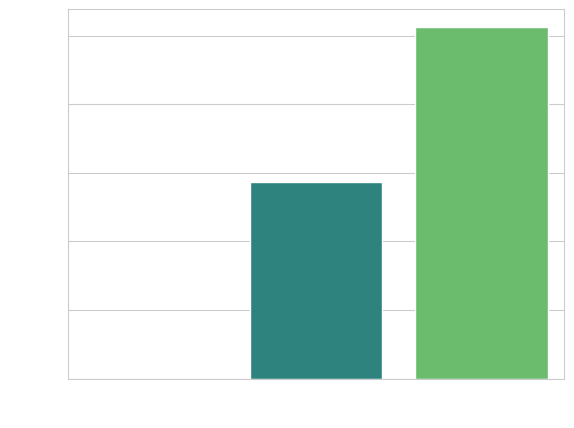

In [505]:
'''
Results reveal that there are no true non-users. AI use is ubiquitous among students.
'''

# Create a count plot showing the distribution of students across user groups
ax = sns.countplot(data=stud,              # Use the student dataframe
              x='user_group',              # Plot user groups on x-axis
              hue='user_group',            # Color bars by user group
              palette = 'viridis',         # Use viridis color palette
              dodge=False                  # Don't separate bars by hue
             )

# Add count labels to each bar in the plot with white text
ax.bar_label(ax.containers[0], fontsize=10, color='white')  # Label first group
ax.bar_label(ax.containers[1], fontsize=10, color='white', padding=10)  # Label second group
ax.bar_label(ax.containers[2], fontsize=10, color='white')  # Label third group

# Set axis labels with white text
plt.xlabel('User Group', color='white')
plt.ylabel('Number of Users', color='white')

# Change tick labels to white
ax.tick_params(colors='white')

# Set the legend text color to white (if legend is shown)
legend = ax.get_legend()
if legend:
    for text in legend.get_texts():
        text.set_color('white')

# Save the figure with transparent background
plt.savefig('Distribution of Users', transparent=True)

# Display the plot
plt.show()

In [506]:
stud.user_class.value_counts()

user_class
Moderate    6155
Minimal      931
Heavy        914
Name: count, dtype: int64

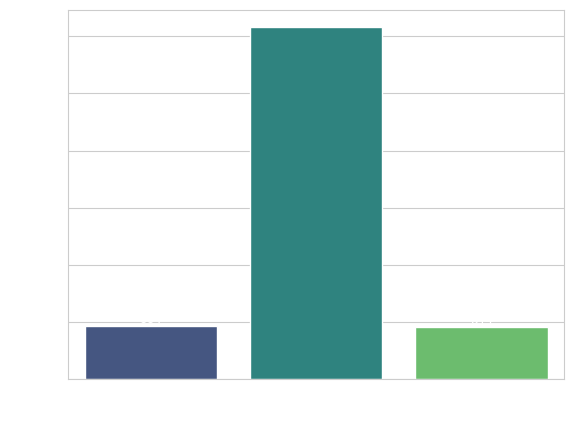

In [507]:
'''
Due to the lack of a true control group (no True Non-Users), the intensity of use is used to create a pseudo-control group. This is the minimal user class. 
'''
# Create a count plot showing the distribution of users across different user classes
ax = sns.countplot(data=stud,  # Use the student dataframe
                   x='user_class',  # X-axis represents user classes
                   hue='user_class',  # Color the bars by user class
                   palette = 'viridis'  # Use reversed viridis color palette
                  )
# Add count labels on top of each bar for each user class
ax.bar_label(ax.containers[0], fontsize=10, color='white')  # Label first user class
ax.bar_label(ax.containers[1], fontsize=10, color='white')  # Label second user class
ax.bar_label(ax.containers[2], fontsize=10, color='white')  # Label third user class
# Set axis labels
plt.xlabel('Usage Intensity Group', color='white')
plt.ylabel('Number of Users',color='white')

# Change tick labels to white
ax.tick_params(colors='white')

# Set the legend text color to white (if legend is shown)
legend = ax.get_legend()
if legend:
    for text in legend.get_texts():
        text.set_color('white')

plt.savefig('Distribution of Users by Usage Intensity', transparent=True)
# Display the plot
plt.show()

In [508]:
# Parameters
N_population = 8000
n_sample = 931
std_dev = 17.5  # Approximate standard deviation of improvement_rate from your data
z_score = 1.96  # For 95% Confidence Level

# Standard Error calculation
standard_error = std_dev / np.sqrt(n_sample)

# Finite Population Correction (optional, but good since n > 5% of N)
fpc = np.sqrt((N_population - n_sample) / (N_population - 1))

# Margin of Error
margin_of_error = z_score * standard_error * fpc

print(f"Control Group Size: {n_sample} ({n_sample/N_population:.1%})")
print(f"Margin of Error at 95% Confidence: ±{margin_of_error:.2f}%")

Control Group Size: 931 (11.6%)
Margin of Error at 95% Confidence: ±1.06%


# 2. How does the manner of use affect Academic Outcomes

## A. Usage Intesity

C:\Users\justi\AppData\Local\Temp\ipykernel_9568\1501368447.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


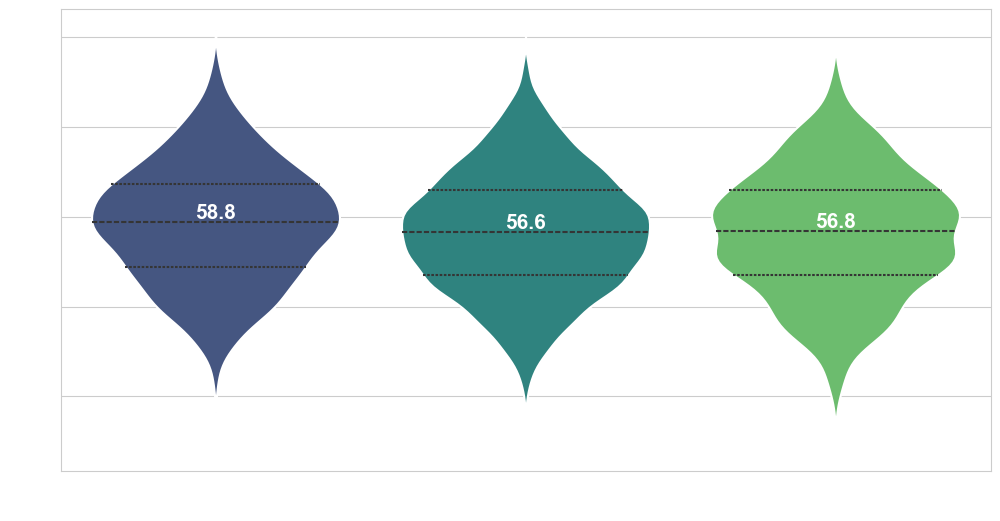

In [509]:
# Final Scores by User Class (Violin Plot version)
plt.figure(figsize=(12,6))  # Create a new figure with specified size (width=12, height=6 inches)

# Create the violin plot
ax = sns.violinplot(
    data=stud,                # DataFrame containing our student data
    x='user_class',           # Column to use for x-axis categories (usage intensity groups)
    y='final_score',          # Column to use for y-axis values (student final scores)
    palette='viridis',        # Color palette for different violins
    inner='quartile',         # Shows the quartiles inside the violin plot
    linewidth=1.5             # Width of the outline of the violins
)

# Set the outline/edge colors to white for the dark theme
for poly in ax.collections:   # Loop through all violin shapes in the plot
    poly.set_edgecolor('white')  # Change the outline color to white

# 1. Calculate medians and add text labels
# It's more reliable to get medians from the data for violin plots
medians = stud.groupby('user_class',observed=False)['final_score'].median()  # Calculate median score for each user class
categories = [t.get_text() for t in ax.get_xticklabels()]  # Get the category names from x-axis labels

for i, label in enumerate(categories):  # Loop through each category
    median_val = medians[label]  # Get the median value for this category
    
    # 2. Add the text label
    ax.text(
        i,                    # x-position (index of the category)
        median_val,           # y-position (at the median value)
        f'{median_val:.1f}',  # Text to display (median value with 1 decimal place)
        ha='center',          # Horizontal alignment centered
        va='bottom',          # Vertical alignment below the point
        fontsize=15,          # Size of the text
        fontweight='bold',    # Make the text bold
        color='white'         # Text color white to match dark theme
    )

# Styling
ax.tick_params(colors='white')  # Set tick colors to white
plt.xlabel('Usage Intensity Group', color='white')  # Set x-axis label with white color
plt.ylabel('Final Score', color='white')  # Set y-axis label with white color
plt.savefig('Final Score Distribution by Usage Intensity_Violin', transparent=True)  # Save the figure with transparent background
plt.show()  # Display the plot

In [510]:
#Statistical Check for final scores
minimal_scores = stud[stud['user_class'] == 'Minimal']['final_score']
moderate_scores = stud[stud['user_class'] == 'Moderate']['final_score']
heavy_scores = stud[stud['user_class'] == 'Heavy']['final_score']

In [511]:
get_anova('user_class', 'final_score')

F-Statistic: 7.92
P-Value: 3.68e-04
Statistically Significant
--------------------


In [512]:
f_stat, p_val = stats.f_oneway(minimal_scores, moderate_scores, heavy_scores)
print(f"ANOVA Results (Minimal vs Moderate vs Heavy):")
print(f"F-Statistic {f_stat:.2f}")
print(f"P-Value {p_val:.4f}")

if p_val <.05:
    print("Result: Statistically significant difference between groups.")
else:
    print("Result: No statsitically significant difference found.")

ANOVA Results (Minimal vs Moderate vs Heavy):
F-Statistic 7.92
P-Value 0.0004
Result: Statistically significant difference between groups.


In [513]:
f_stat, p_val = stats.f_oneway(minimal_scores, moderate_scores)
print(f"ANOVA Results (Minimal vs Moderate):")
print(f"F-Statistic {f_stat:.2f}")
print(f"P-Value {p_val:.4f}")

if p_val <.05:
    print("Result: Statistically significant difference between groups.")
else:
    print("Result: No statsitically significant difference found.")

ANOVA Results (Minimal vs Moderate):
F-Statistic 14.02
P-Value 0.0002
Result: Statistically significant difference between groups.


In [514]:
f_stat, p_val = stats.f_oneway(minimal_scores, heavy_scores)
print(f"ANOVA Results (Minimal vs Heavy):")
print(f"F-Statistic {f_stat:.2f}")
print(f"P-Value {p_val:.4f}")

if p_val <.05:
    print("Result: Statistically significant difference between groups.")
else:
    print("Result: No statsitically significant difference found.")

ANOVA Results (Minimal vs Heavy):
F-Statistic 12.23
P-Value 0.0005
Result: Statistically significant difference between groups.


In [515]:
f_stat, p_val = stats.f_oneway(moderate_scores, heavy_scores)
print(f"ANOVA Results (Moderate vs Heavy):")
print(f"F-Statistic {f_stat:.2f}")
print(f"P-Value {p_val:.4f}")

if p_val <.05:
    print("Result: Statistically significant difference between groups.")
else:
    print("Result: No statsitically significant difference found.")

ANOVA Results (Moderate vs Heavy):
F-Statistic 0.75
P-Value 0.3856
Result: No statsitically significant difference found.


In [516]:
'''
Results, there is no statistical difference between Minimal Users' Final Scores and Moderate Users' Final Scores, 
but there was a statistically significant difference between Heavy Users and both Minimal and Moderate Users' Final Scores
'''

"\nResults, there is no statistical difference between Minimal Users' Final Scores and Moderate Users' Final Scores, \nbut there was a statistically significant difference between Heavy Users and both Minimal and Moderate Users' Final Scores\n"

C:\Users\justi\AppData\Local\Temp\ipykernel_9568\221390170.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=stud,            # Use the 'stud' dataframe as the data source


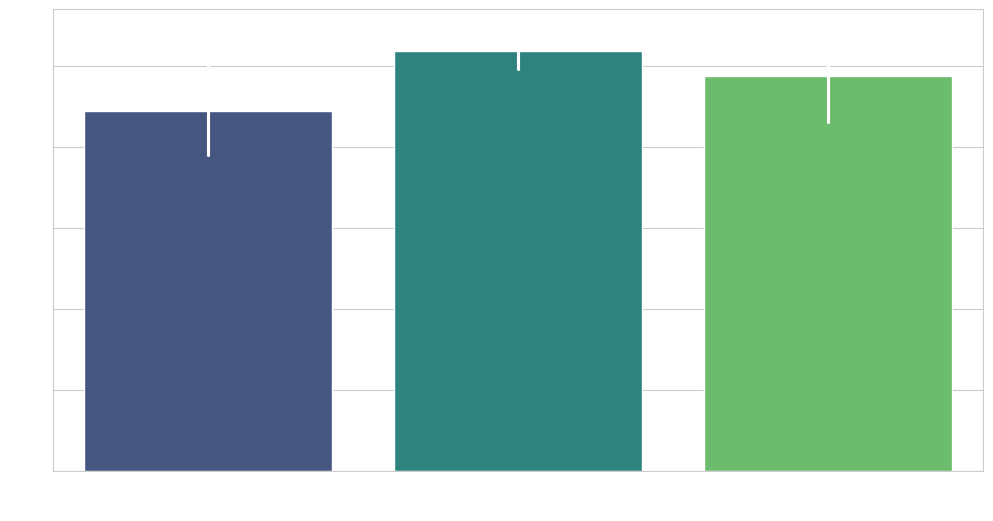

In [517]:
# Create a figure with specified size (width=12, height=6 inches)
plt.figure(figsize=(12,6))

# Create a bar plot showing the mean improvement rate for each user class
ax = sns.barplot(data=stud,            # Use the 'stud' dataframe as the data source
            x='user_class',            # Use 'user_class' column for x-axis categories
            y='improvement_rate',      # Use 'improvement_rate' column for y-axis values
            estimator=np.mean,         # Calculate the mean of improvement_rate for each user class
            errorbar=('ci',95),        # Show 95% confidence interval error bars
            palette='viridis',         # Use the 'viridis' color palette
            err_kws = {'color':'white'}
        )

# Add labels to each bar in the first container (likely the first user class)
ax.bar_label(ax.containers[0], fontsize=10, padding=35, color='white')
# Add labels to each bar in the second container (likely the second user class)
ax.bar_label(ax.containers[1], fontsize=10, padding=18, color='white')
# Add labels to each bar in the third container (likely the third user class)
ax.bar_label(ax.containers[2], fontsize=10, padding=35, color='white')
ax.tick_params(colors='white')
# Set the title of the plot
#plt.title("Average Improvement rate by User Class")
# Set the x- and y-axis labels
plt.ylabel('Average Improvement Rate (%)', color='white')
plt.xlabel('Usage Intensity Group', color='white')
plt.savefig('Average Improvement Rate by Usage Intensity', transparent=True)
# Display the plot
plt.show()

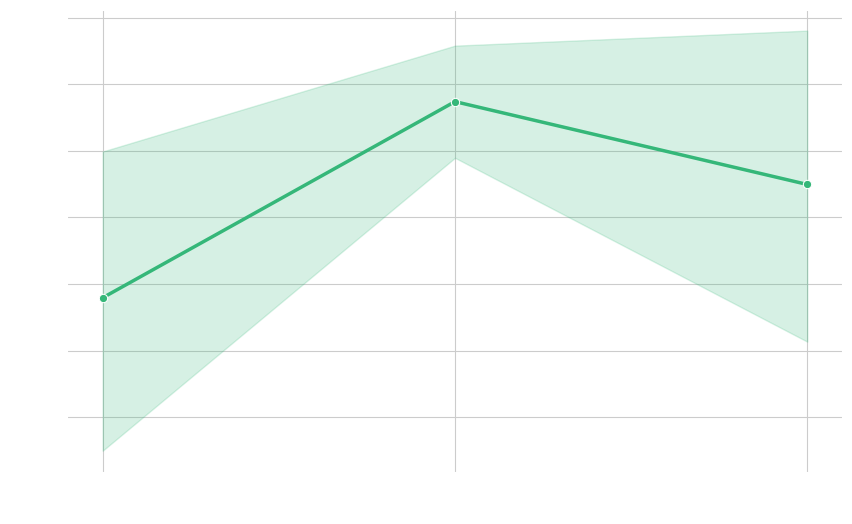

In [518]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Create a point plot (similar to a line chart for categories)
# This shows the Mean Improvement Rate with a 95% Confidence Interval
ax = sns.lineplot(
    data=stud,
    x='user_class', 
    y='improvement_rate',
    marker='o',       # Adds dots at each data point
    color=full_palette[13],  # A distinct green color
    linewidth=2.5
)

# Customize labels and title
#plt.title('Average Improvement Rate by AI Usage Intensity', color='white', fontsize=14)
plt.xlabel('Usage Intensity Group', color='white', fontsize=12)
plt.ylabel('Average Improvement Rate (%)', color='white', fontsize=12)

# Adjust tick colors for the dark background
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')

# Save and Show
plt.savefig('Improvement_Rate_Line_UserClass.png', transparent=True)
plt.show()

In [519]:
#Statistical Check for improvement rate
minimal_imp_rate = stud[stud['user_class'] == 'Minimal']['improvement_rate']
moderate_imp_rate = stud[stud['user_class'] == 'Moderate']['improvement_rate']
heavy_imp_rate = stud[stud['user_class'] == 'Heavy']['improvement_rate']

In [520]:
get_anova('user_class', 'improvement_rate')

F-Statistic: 3.11
P-Value: 4.45e-02
Statistically Significant
--------------------


In [521]:
f_stat, p_val = stats.f_oneway(minimal_imp_rate, moderate_imp_rate, heavy_imp_rate)
print(f"ANOVA Results (Minimal vs Moderate vs Heavy):")
print(f"F-Statistic {f_stat:.2f}")
print(f"P-Value {p_val:.4f}")

if p_val <.05:
    print("Result: Statistically significant difference between groups.")
else:
    print("Result: No statsitically significant difference found.")

ANOVA Results (Minimal vs Moderate vs Heavy):
F-Statistic 3.11
P-Value 0.0445
Result: Statistically significant difference between groups.


In [522]:
f_stat, p_val = stats.f_oneway(minimal_imp_rate, moderate_imp_rate)
print(f"ANOVA Results (Minimal vs Moderate):")
print(f"F-Statistic {f_stat:.2f}")
print(f"P-Value {p_val:.4f}")

if p_val <.05:
    print("Result: Statistically significant difference between groups.")
else:
    print("Result: No statsitically significant difference found.")

ANOVA Results (Minimal vs Moderate):
F-Statistic 5.76
P-Value 0.0164
Result: Statistically significant difference between groups.


In [523]:
f_stat, p_val = stats.f_oneway(minimal_imp_rate, heavy_imp_rate)
print(f"ANOVA Results (Minimal vs Heavy):")
print(f"F-Statistic {f_stat:.2f}")
print(f"P-Value {p_val:.4f}")

if p_val <.05:
    print("Result: Statistically significant difference between groups.")
else:
    print("Result: No statsitically significant difference found.")

ANOVA Results (Minimal vs Heavy):
F-Statistic 1.07
P-Value 0.3008
Result: No statsitically significant difference found.


In [524]:
f_stat, p_val = stats.f_oneway(moderate_imp_rate, heavy_imp_rate)
print(f"ANOVA Results (Heavy vs Moderate):")
print(f"F-Statistic {f_stat:.2f}")
print(f"P-Value {p_val:.4f}")

if p_val <.05:
    print("Result: Statistically significant difference between groups.")
else:
    print("Result: No statsitically significant difference found.")

ANOVA Results (Heavy vs Moderate):
F-Statistic 1.01
P-Value 0.3151
Result: No statsitically significant difference found.


In [525]:
'''
There is no statistical difference between Heavy Users' Rates of Improvement and both Moderate and Minimal Users' Rates
but there was a statistical difference between Minimal and Moderate Users' Rates of Improvement.
'''

"\nThere is no statistical difference between Heavy Users' Rates of Improvement and both Moderate and Minimal Users' Rates\nbut there was a statistical difference between Minimal and Moderate Users' Rates of Improvement.\n"

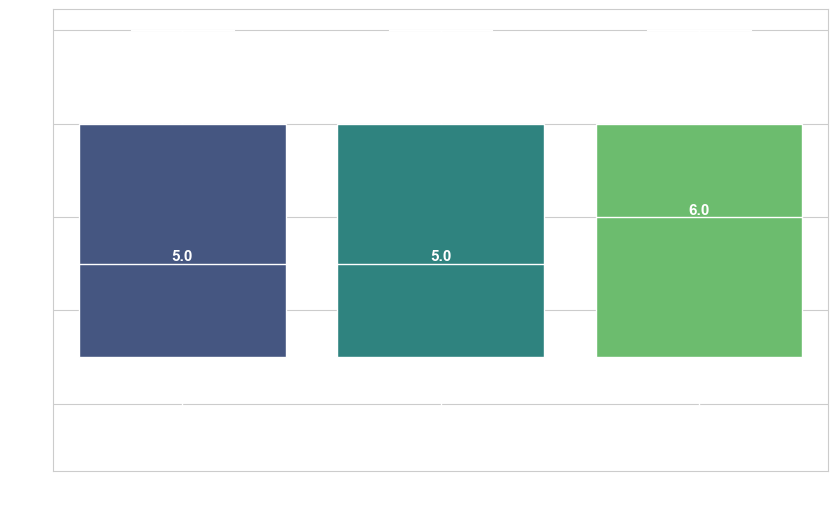

In [526]:
# Analysis: Concept Understanding by Usage Intensity
# Question: Does the intensity of AI usage impact the depth of concept understanding?

# 1. Visualization: Boxplot
# Analysis: Concept Understanding by Usage Intensity
# Question: Does the intensity of AI usage impact the depth of concept understanding?

# 1. Visualization: Boxplot
plt.figure(figsize=(10, 6))  # Create a new figure with specified size
ax = sns.boxplot(
            data=stud,  # Dataset containing student information
            x='user_class',  # X-axis: AI usage intensity categories
            y='concept_understanding_score',  # Y-axis: Score measuring concept understanding
            hue='user_class',   # <--- FIX 1: Assign the same column to hue for consistent coloring
            palette='viridis',  # Color palette for the boxplots
            boxprops=dict(edgecolor='white'),  # Set box edge color to white
            whiskerprops=dict(color='white'),  # Set whisker color to white
            capprops=dict(color='white'),  # Set cap color to white
            medianprops=dict(color='white'),  # Set median line color to white
            
)

# Add median labels to each boxplot
lines = ax.get_lines()  # Get all lines in the plot
categories = ax.get_xticks()  # Get x-axis tick positions

for cat in categories:
    # Each boxplot has 6 lines (whiskers, caps, box, median). The median is the 5th line (index 4)
    # This logic finds the median line for each category
    median_line = lines[4 + cat * 6]  # Calculate index of median line for current category
    x_coords, y_coords = median_line.get_data()  # Get coordinates of the median line
    x_val = np.mean(x_coords)  # Calculate x position for text (center of line)
    y_val = y_coords[0]  # Get y value (the median value)

    # Add text label showing the median value
    ax.text(
        x_val, 
        y_val, 
        f'{y_val:.1f}',  # Format median value to 1 decimal place
        ha='center',  # Horizontally center the text
        va='bottom',  # Position text below the point
        fontweight='bold',  # Make text bold
        color='white',  # Text color
        fontsize=11  # Text size
    )

lines = ax.get_lines()  # This line is redundant as lines are already defined above
categories = ax.get_xticks()  # This line is redundant as categories are already defined above


ax.tick_params(colors='white')  # Set tick colors to white
plt.ylabel('Concept Understanding Score', color='white')  # Set y-axis label with white color
plt.xlabel('Usage Intensity Group', color='white')  # Set x-axis label with white color
plt.savefig('Concept Unstanding Score by Usage Intensity', transparent=True)  # Save figure with transparent background
plt.show()  # Display the plot

In [527]:
get_anova('user_class', 'concept_understanding_score')

F-Statistic: 1.44
P-Value: 2.37e-01
Not Significant
--------------------


C:\Users\justi\AppData\Local\Temp\ipykernel_9568\480852977.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxenplot(x='user_class',                  # X-axis: different user classes


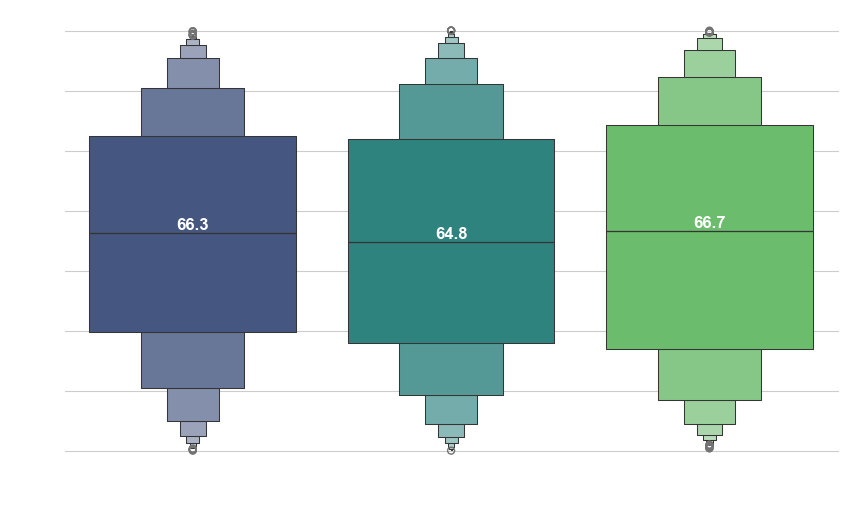

In [528]:
# Set up the figure with a specific size (10 inches width, 6 inches height)
plt.figure(figsize=(10, 6))

# Create a boxplot using seaborn to visualize the distribution of assignment scores across user classes
ax = sns.boxenplot(x='user_class',                  # X-axis: different user classes
                 y='assignment_scores_avg',        # Y-axis: average assignment scores
                 data=stud,                        # Data source: stud dataframe
                 palette='viridis',                # Color scheme for the boxes
                 # boxprops=dict(edgecolor='white'),  # Set box edge color to white for better visibility
                 # whiskerprops=dict(color='white'),  # Set whisker color to white
                 # capprops=dict(color='white'),      # Set cap color to white
                 # medianprops=dict(color='white'),   # Set median line color to white
                 # flierprops=dict(markeredgecolor='white')  # Set outlier edge color to white
                )

# --- Styling for White Text (for dark background) ---
#ax.set_title('Assignment Score by Usage Intensity', color='white', fontsize=14, pad=20)
ax.set_xlabel('Usage Intensity Group', color='white', fontsize=12)  # Set x-axis label with white color
ax.set_ylabel('Average Assignment Score', color='white', fontsize=12)  # Set y-axis label with white color
ax.tick_params(axis='x', colors='white')  # Make x-axis tick labels white
ax.tick_params(axis='y', colors='white')  # Make y-axis tick labels white
for spine in ax.spines.values():
    spine.set_edgecolor('white')  # Make all plot borders white

# --- Calculate and annotate median values on the boxplot ---
medians = stud.groupby('user_class', observed=False)['assignment_scores_avg'].median()  # Calculate median for each user class
xtick_labels = [label.get_text() for label in ax.get_xticklabels()]  # Get the x-tick labels

# Add text annotations for each median value
for i, label in enumerate(xtick_labels):
    if label in medians.index:
        val = medians[label]
        ax.text(i, val, f'{val:.1f}',  # Position text at (i, val) with 1 decimal place
                horizontalalignment='center',  # Center text horizontally
                verticalalignment='bottom',    # Position text below the point
                color='white',                 # White text color
                fontweight='bold',             # Bold text
                fontsize=12                    # Text size
                )

# Save the figure with transparent background (for embedding in documents with dark backgrounds)
plt.savefig('boxplot_user_class.png', transparent=True)
plt.show()  # Display the plot

In [529]:
get_anova('user_class', 'assignment_scores_avg')

F-Statistic: 1.46
P-Value: 2.33e-01
Not Significant
--------------------


## B. AI Tools

In [530]:
stud_tools = stud[~stud['ai_tools_used'].isin(['None', 'Unknown'])].copy()

C:\Users\justi\AppData\Local\Temp\ipykernel_9568\3049248427.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=stud,


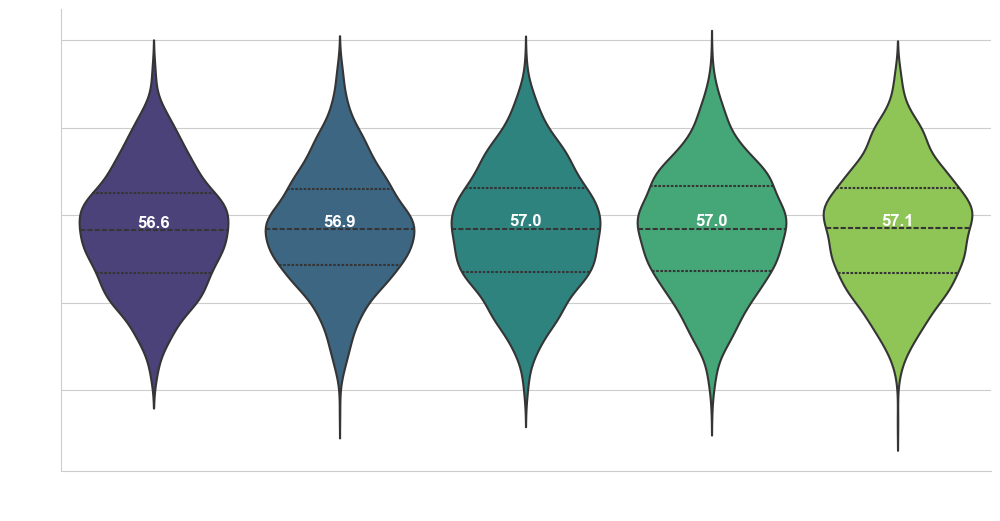

In [531]:
#Tool Effectiveness (Violin Plot)
plt.figure(figsize=(12, 6))  # Create a new figure with specified size

# Sort order by median performance to display tools from lowest to highest median score
tool_order = stud_tools.groupby('ai_tools_used')['final_score'].median().sort_values().index

# Create the violin plot
ax = sns.violinplot(data=stud,
            x='ai_tools_used',  # AI tools on x-axis
            y='final_score',    # Final scores on y-axis
            order=tool_order,   # Use the sorted order of tools
            #hue='user_class',  # Commented out color grouping by user class
            palette='viridis',  # Use viridis color palette
            inner='quartile',   # Shows the quartiles inside the violin
            linewidth=1.5       # Width of the outline
           )

# Style the inner lines (whiskers and box) to be white
# Note: This comment is present but the implementation is missing

# Annotate Medians
# Calculate medians directly from data for accurate labeling
medians = stud.groupby('ai_tools_used')['final_score'].median()

# Loop through each tool and add its median score as a text label
for i, label in enumerate(tool_order):
    val = medians[label]
    # Add text label with median value
    ax.text(
        i,                # x-position (tool index)
        val,              # y-position (at the median value)
        f'{val:.1f}',     # Text showing median with 1 decimal place
        ha='center',      # Horizontally center the text
        va='bottom',      # Position text at the bottom of the point
        fontsize=12,      # Text size
        fontweight='bold',# Make text bold
        color='white',    # Text color
    )

# Styling axis labels and ticks
ax.tick_params(colors='white')  # Make tick labels white
plt.ylabel('Final Score', color='white')  # Y-axis label with white color
plt.xlabel('AI Tool', color='white')      # X-axis label with white color

# Remove the top and right spines for a cleaner look
sns.despine()

# Save the figure with transparent background
plt.savefig('Final Score by AI Tool Used_Violin', transparent=True)
plt.show()  # Display the plot

In [532]:
get_anova('ai_tools_used', 'final_score')

F-Statistic: 0.35
P-Value: 9.13e-01
Not Significant
--------------------


C:\Users\justi\AppData\Local\Temp\ipykernel_9568\2078160833.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


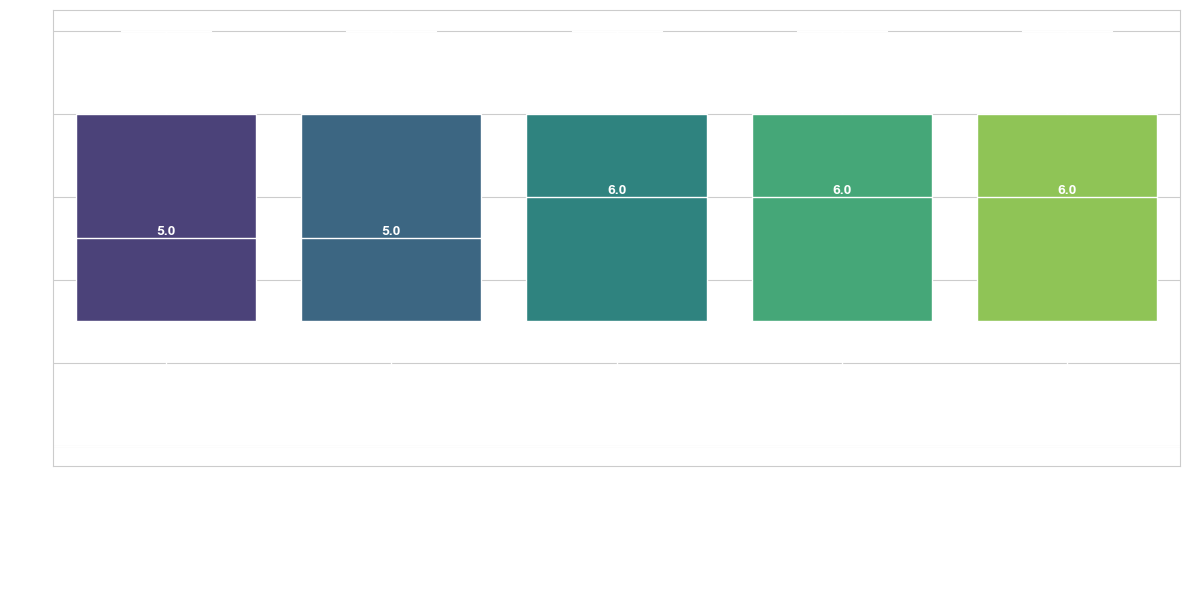

In [533]:
# Analysis: Does the PURPOSE of AI use impact Concept Understanding?
# Hypothesis: Passive uses (generating answers) might hurt, active uses (debugging) might help.

# Create a figure with specified size
plt.figure(figsize=(12, 6))

# Sort tools by median concept understanding score (ascending order)
tool_order = stud_tools.groupby('ai_tools_used')['concept_understanding_score'].median().sort_values(ascending=True).index

# Create boxplot showing concept understanding score distribution by AI tool
ax = sns.boxplot(
    data=stud,
    x='ai_tools_used',
    y='concept_understanding_score',
    #hue='user_class',  # Commented out but could be used to add another grouping dimension
    order=tool_order,  # Use the sorted order of tools
    palette='viridis',  # Color scheme
    # Set all box elements to white for better visibility on dark background
    boxprops=dict(edgecolor='white'),
    whiskerprops=dict(color='white'),
    capprops=dict(color='white'),
    medianprops=dict(color='white'),
    flierprops=dict(markeredgecolor='white')
)

# Add median value labels to each box
lines = ax.get_lines()
categories = ax.get_xticks()

for cat_idx in categories:
    # In seaborn boxplots, the median is the 5th line (index 4) in each group of 6 lines per box
    median_line = lines[4 + cat_idx * 6]
    x_coords, y_coords = median_line.get_data()
    x_val = np.mean(x_coords)  # Get x position (center of the box)
    y_val = y_coords[0]        # Get y position (median value)

    # Add text label showing the median value
    ax.text(
        x_val, 
        y_val, 
        f'{y_val:.1f}',  # Format to 1 decimal place
        ha='center',     # Horizontally centered
        va='bottom',     # Position text below the point
        fontweight='bold', 
        color='white',
        fontsize=10
    )

# Set tick colors to white for dark background compatibility
ax.tick_params(colors='white')

# Add axis labels with white text
plt.xlabel('AI Tool', color='white')
plt.ylabel('Concept Understanding Score', color='white')

# Add a horizontal line at y=0 for reference
plt.axhline(0, color='white', linewidth=1)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent clipping
plt.tight_layout()

# Save figure with transparent background
plt.savefig('Concept Understanding by AI Tools', transparent=True)

# Display the plot
plt.show()

In [534]:
get_anova('ai_tools_used', 'concept_understanding_score')

F-Statistic: 0.52
P-Value: 7.95e-01
Not Significant
--------------------


C:\Users\justi\AppData\Local\Temp\ipykernel_9568\4191667236.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=stud,            # Use the 'stud' dataframe as the data source


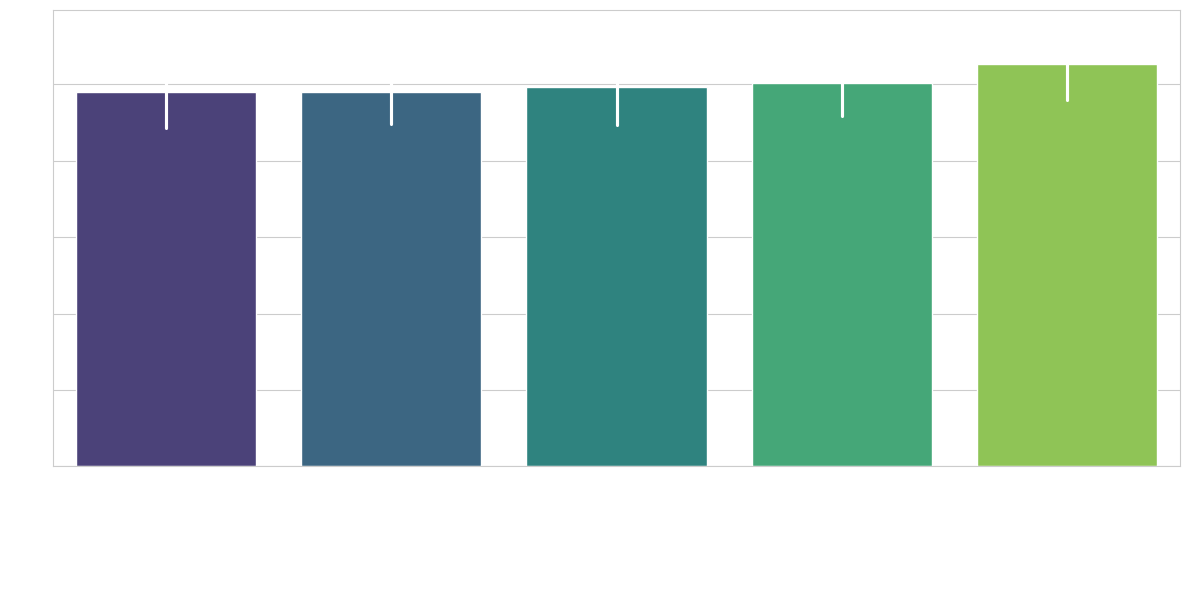

In [535]:
# Set figure size to 12 inches width and 6 inches height
plt.figure(figsize=(12,6))

# Sort AI tools by mean improvement rate in ascending order to create ordered visualization
tool_order = stud_tools.groupby('ai_tools_used')['improvement_rate'].mean().sort_values(ascending=True).index

# Create a bar plot showing the mean improvement rate for each AI tool
ax = sns.barplot(data=stud,            # Use the 'stud' dataframe as the data source
            x='ai_tools_used',         # Use 'ai_tools_used' column for x-axis categories
            y='improvement_rate',      # Use 'improvement_rate' column for y-axis values
            estimator=np.mean,         # Calculate the mean of improvement_rate for each AI tool
            errorbar=('ci',95),        # Show 95% confidence interval error bars
            palette='viridis',         # Use the 'viridis' color palette
            err_kws = {'color':'white'}, # Set error bar color to white
            order=tool_order           # Display bars in the sorted order defined above
        )

# Add white labels to each bar showing the exact values
# Each container represents a group in the plot
ax.bar_label(ax.containers[0], fontsize=10, padding=30, color='white')
ax.bar_label(ax.containers[1], fontsize=10, padding=30, color='white')
ax.bar_label(ax.containers[2], fontsize=10, padding=30, color='white')
ax.bar_label(ax.containers[3], fontsize=10, padding=30, color='white')
ax.bar_label(ax.containers[4], fontsize=10, padding=27, color='white')
# Commented out labels for containers that may not exist in the current dataset
#ax.bar_label(ax.containers[5], fontsize=10, padding=26, color='white')
#ax.bar_label(ax.containers[6], fontsize=10, padding=30, color='white')

# Customize plot appearance with white text for better visibility on dark backgrounds
ax.tick_params(colors='white')  # Set tick labels to white

plt.ylabel('Improvement Rate (%)', color='white')  # Set y-axis label with white text
plt.xlabel('AI Tool', color='white')  # Set x-axis label with white text
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of labels

# Save the figure with transparent background and display it
plt.savefig('Improvement Rate by AI Tool Used', transparent=True)
plt.show()

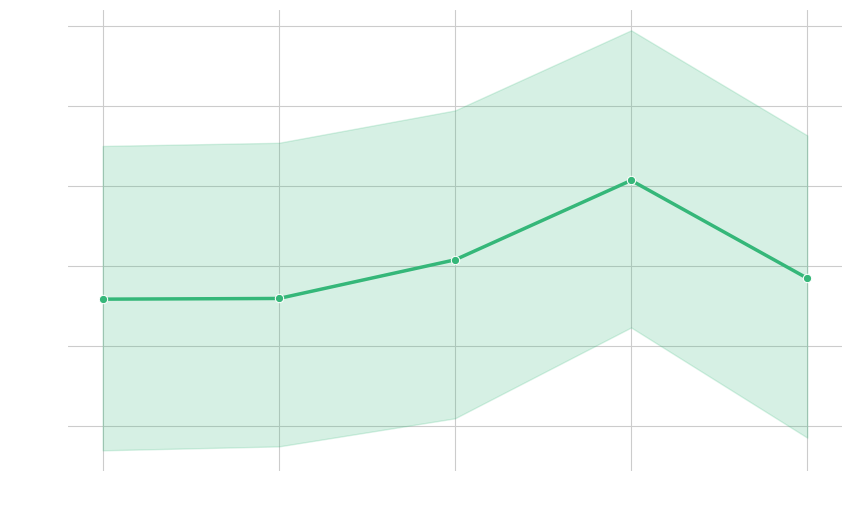

In [536]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Create a point plot (similar to a line chart for categories)
# This shows the Mean Improvement Rate with a 95% Confidence Interval
ax = sns.lineplot(
    data=stud_tools,
    x='ai_tools_used', 
    y='improvement_rate',
    marker='o',       # Adds dots at each data point
    color=full_palette[13],  # A distinct green color
    linewidth=2.5
)

# Customize labels and title
#plt.title('Average Improvement Rate by AI Usage Intensity', color='white', fontsize=14)
plt.xlabel('AI Tool', color='white', fontsize=12)
plt.ylabel('Average Improvement Rate (%)', color='white', fontsize=12)

# Adjust tick colors for the dark background
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')

# Save and Show
plt.savefig('Improvement_Rate_Line_Tool.png', transparent=True)
plt.show()

In [537]:
get_anova('ai_tools_used', 'improvement_rate')

F-Statistic: 0.85
P-Value: 5.34e-01
Not Significant
--------------------


C:\Users\justi\AppData\Local\Temp\ipykernel_9568\367237985.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxenplot(x='ai_tools_used',          # X-axis: different AI tools


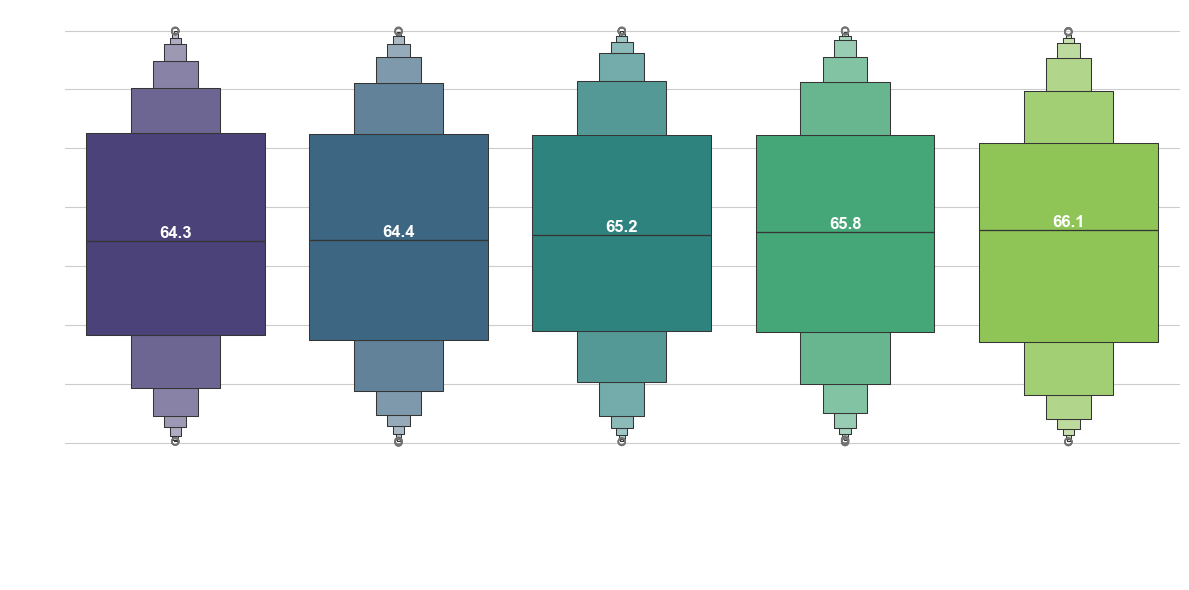

In [538]:
# Set up the figure size for the visualization
plt.figure(figsize=(12, 6))

# Order the AI tools based on median assignment scores (ascending order)
# This creates a sorted index that will be used to arrange the boxplots
tool_order = stud_tools.groupby('ai_tools_used')['assignment_scores_avg'].median().sort_values(ascending=True).index

# Create a boxplot showing the distribution of assignment scores for each AI tool
ax = sns.boxenplot(x='ai_tools_used',          # X-axis: different AI tools
                 y='assignment_scores_avg',   # Y-axis: average assignment scores
                 data=stud,                   # Dataset to use
                 palette='viridis',           # Color scheme
                 order=tool_order,            # Custom ordering of boxes
                 # boxprops=dict(edgecolor='white'),      # White edges for the boxes
                 # whiskerprops=dict(color='white'),      # White whiskers
                 # capprops=dict(color='white'),          # White caps on whiskers
                 # medianprops=dict(color='white'),       # White median lines
                 # flierprops=dict(markeredgecolor='white')  # White outlines for outlier points
                )

# --- Styling the plot ---
#ax.set_title('Assignment Score by AI Tools Used', color='white', fontsize=14, pad=20)
ax.set_xlabel('AI Tools Used', color='white', fontsize=12)           # Set and style x-axis label
ax.set_ylabel('Average Assignment Score', color='white', fontsize=12)  # Set and style y-axis label
ax.tick_params(axis='x', colors='white', rotation=45)  # Rotate x-axis labels by 45° and make them white
ax.tick_params(axis='y', colors='white')               # Make y-axis tick labels white
for spine in ax.spines.values():
    spine.set_edgecolor('white')                       # Make all plot borders white

# --- Add median values as text annotations on the boxplot ---
medians = stud.groupby('ai_tools_used')['assignment_scores_avg'].median()  # Calculate median for each tool
xtick_labels = [label.get_text() for label in ax.get_xticklabels()]        # Get x-axis labels

# Loop through each box position and add the median value as text
for i, label in enumerate(xtick_labels):
    if label in medians.index:
        val = medians[label]
        ax.text(i, val, f'{val:.1f}',                # Add text with 1 decimal place
                horizontalalignment='center',         # Center text horizontally
                verticalalignment='bottom',           # Position text below the point
                color='white',                        # White text color
                fontweight='bold',                    # Bold text
                fontsize=12                           # Text size
               )

# Adjust layout and save the figure
plt.tight_layout()                                    # Optimize spacing
plt.savefig('boxplot_ai_tools.png', transparent=True) # Save with transparent background
plt.show()                                            # Display the plot

In [539]:
get_anova('ai_tools_used', 'assignment_scores_avg')

F-Statistic: 0.42
P-Value: 8.67e-01
Not Significant
--------------------


## C. AI Usage Purpose

In [540]:
# 1. Create a filtered DataFrame excluding 'None' and 'Unknown'
stud_purpose = stud[~stud['ai_usage_purpose'].isin(['None', 'Unknown'])].copy()

C:\Users\justi\AppData\Local\Temp\ipykernel_9568\431472930.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=stud,


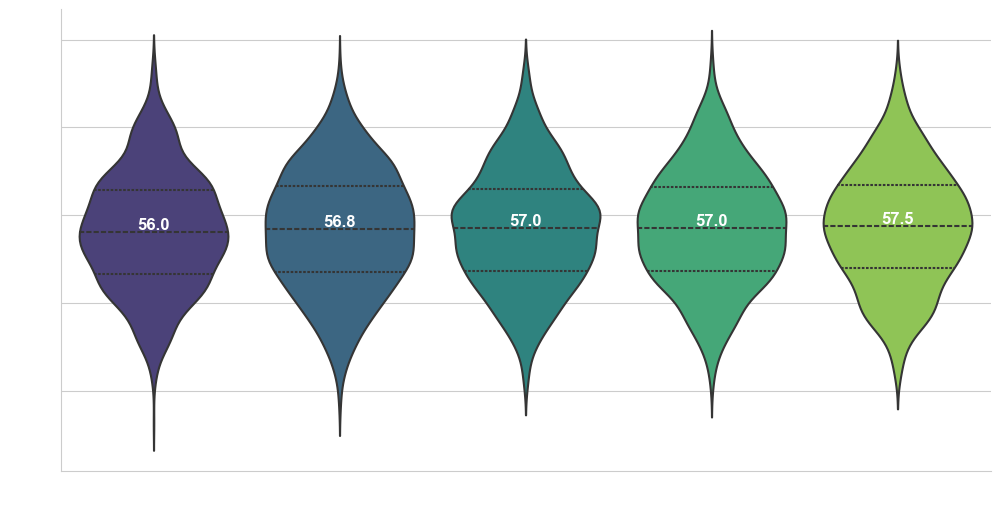

In [554]:
#Usage Effectiveness (Violin Plot)
plt.figure(figsize=(12, 6))

# Sort order by median performance to display purposes from lowest to highest median score
purpose_order = stud_purpose.groupby('ai_usage_purpose')['final_score'].median().sort_values().index

# Create the violin plot showing distribution of final scores by AI usage purpose
ax = sns.violinplot(data=stud,
            x='ai_usage_purpose',  # Categories on x-axis (different AI usage purposes)
            y='final_score',       # Values on y-axis (student performance)
            order=purpose_order,   # Use the sorted order we defined above
            #hue='user_class',     # Commented out but could be used to add another grouping variable
            palette='viridis',     # Color scheme
            inner='quartile',      # Shows the quartiles inside the violin plots
            linewidth=1.5          # Width of the outline
           )

# Style the inner lines (whiskers and box) to be white
# Note: This comment was in original code but the implementation is missing

# Annotate Medians on the plot
# Calculate medians directly from data for accurate labeling
medians = stud.groupby('ai_usage_purpose')['final_score'].median()

# Loop through each category and add its median value as text
for i, label in enumerate(purpose_order):
    val = medians[label]
    # Add text label with the median value
    ax.text(
        i,                # x-position (category index)
        val,              # y-position (at the median value)
        f'{val:.1f}',     # Text to display (formatted to 1 decimal place)
        ha='center',      # Horizontal alignment
        va='bottom',      # Vertical alignment
        fontsize=12,      # Text size
        fontweight='bold',# Make text bold
        color='white',    # Text color
    )

# Styling the axes
ax.tick_params(colors='white')  # Make tick labels white
plt.ylabel('Final Score', color='white')  # Y-axis label with white color
plt.xlabel('Usage Purpose', color='white')        # X-axis label with white color

# Remove the top and right spines for a cleaner look
sns.despine()

# Save the figure with transparent background
plt.savefig('Final Score by AI Usage Violin', transparent=True)

# Display the plot
plt.show()

In [542]:
get_anova('ai_usage_purpose', 'final_score')

F-Statistic: 0.60
P-Value: 7.30e-01
Not Significant
--------------------


C:\Users\justi\AppData\Local\Temp\ipykernel_9568\244129575.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=stud,            # Use the 'stud' dataframe as the data source


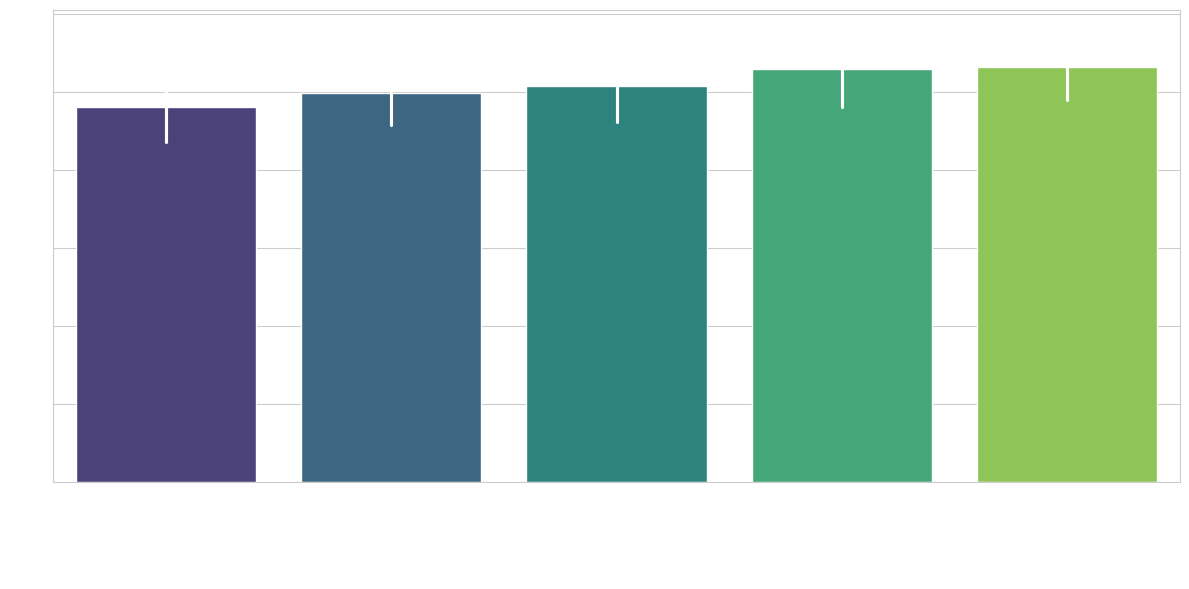

In [543]:
# Create a figure with specified size (width=12, height=6 inches)
plt.figure(figsize=(12,6))

# Sort the purposes by median improvement rate to create a meaningful order for the bars
purpose_order = stud_purpose.groupby('ai_usage_purpose')['improvement_rate'].mean().sort_values().index

# Create a bar plot showing the mean improvement rate for each AI usage purpose
ax = sns.barplot(data=stud,            # Use the 'stud' dataframe as the data source
            x='ai_usage_purpose',      # Use 'ai_usage_purpose' column for x-axis categories
            y='improvement_rate',      # Use 'improvement_rate' column for y-axis values
            estimator=np.mean,         # Calculate the mean of improvement_rate for each purpose
            errorbar=('ci',95),        # Show 95% confidence interval error bars
            palette='viridis',         # Use the 'viridis' color palette
            err_kws = {'color':'white'}, # Set error bar color to white
            order=purpose_order        # Use the sorted order of purposes
        )

# Add labels to each bar with specific positioning and formatting
# Each container represents a group in the plot
ax.bar_label(ax.containers[0], fontsize=10, padding=33, color='white')
ax.bar_label(ax.containers[1], fontsize=10, padding=30, color='white')
ax.bar_label(ax.containers[2], fontsize=10, padding=26, color='white')
ax.bar_label(ax.containers[3], fontsize=10, padding=30, color='white')
ax.bar_label(ax.containers[4], fontsize=10, padding=29, color='white')

# Customize the appearance of the plot
ax.tick_params(colors='white')  # Set tick colors to white

plt.ylabel('Improvement Rate (%)', color='white')  # Set y-axis label with white text
plt.xlabel('Purpose of AI Use', color='white')  # Set x-axis label with white text
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to fit all elements
plt.savefig('Improvement Rate by Usage Purpose', transparent=True)  # Save figure with transparent background

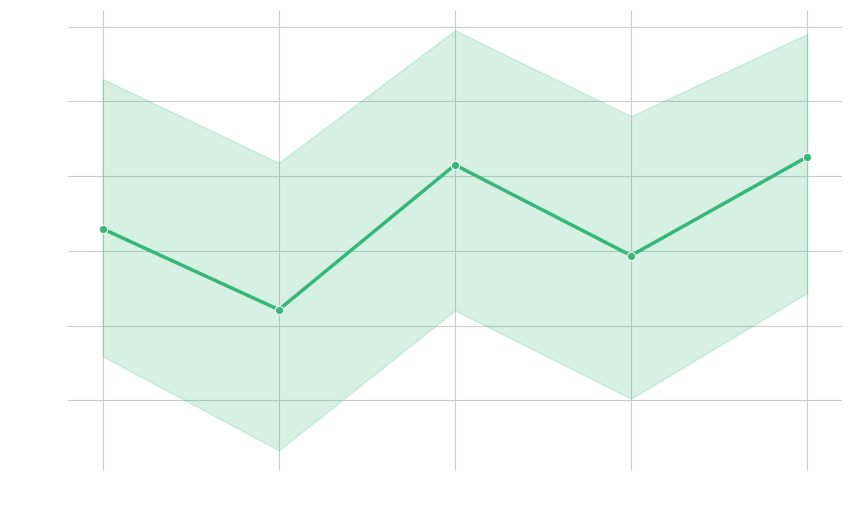

In [544]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Create a point plot (similar to a line chart for categories)
# This shows the Mean Improvement Rate with a 95% Confidence Interval
ax = sns.lineplot(
    data=stud_purpose,
    x='ai_usage_purpose', 
    y='improvement_rate',
    marker='o',       # Adds dots at each data point
    color=full_palette[13],  # A distinct green color
    linewidth=2.5
)

# Customize labels and title
#plt.title('Average Improvement Rate by AI Usage Intensity', color='white', fontsize=14)
plt.xlabel('Purpose of AI Use', color='white', fontsize=12)
plt.ylabel('Average Improvement Rate (%)', color='white', fontsize=12)

# Adjust tick colors for the dark background
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')

# Save and Show
plt.savefig('Improvement_Rate_Line_Use.png', transparent=True)
plt.show()

In [545]:
get_anova('ai_usage_purpose', 'improvement_rate')

F-Statistic: 0.61
P-Value: 7.19e-01
Not Significant
--------------------


C:\Users\justi\AppData\Local\Temp\ipykernel_9568\33861000.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


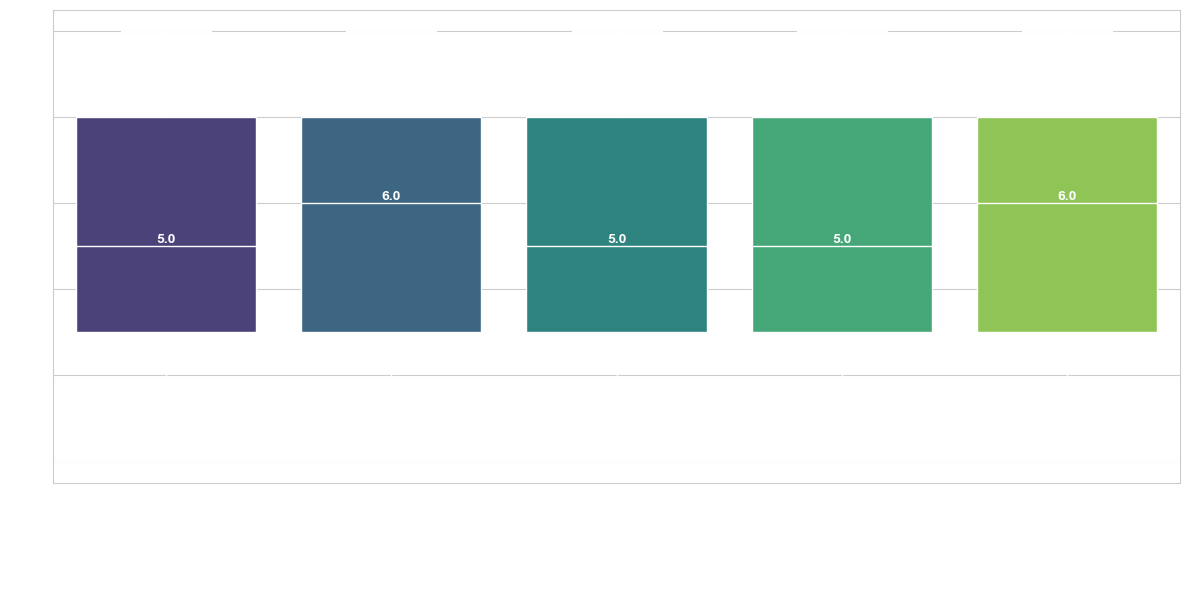

In [546]:
# Analysis: Does the PURPOSE of AI use impact Concept Understanding?
# Hypothesis: Passive uses (generating answers) might hurt, active uses (debugging) might help.

# Create a figure with specified size
plt.figure(figsize=(12, 6))

# Sort purposes by median final score to create a meaningful order for the plot
purpose_order = stud_purpose.groupby('ai_usage_purpose')['final_score'].median().sort_values().index

# Create a boxplot showing concept understanding scores across different AI usage purposes
ax = sns.boxplot(
    data=stud,
    x='ai_usage_purpose',  # X-axis: different purposes for using AI
    y='concept_understanding_score',  # Y-axis: measure of student understanding
    #hue='user_class',  # Commented out color grouping by user class
    order=purpose_order,  # Use the sorted order of purposes
    palette='viridis',  # Color scheme
    # Set all box elements to white for better visibility on dark backgrounds
    boxprops=dict(edgecolor='white'),
    whiskerprops=dict(color='white'),
    capprops=dict(color='white'),
    medianprops=dict(color='white'),
    flierprops=dict(markeredgecolor='white')
)

# Add median value labels to each box
lines = ax.get_lines()
categories = ax.get_xticks()

for cat_idx in categories:
    # In seaborn boxplots, the median line is the 5th line (index 4) in each group of 6 lines per box
    median_line = lines[4 + cat_idx * 6]
    x_coords, y_coords = median_line.get_data()
    x_val = np.mean(x_coords)  # Get x-position (center of the box)
    y_val = y_coords[0]        # Get y-position (median value)

    # Add text label showing the median value
    ax.text(
        x_val, 
        y_val, 
        f'{y_val:.1f}',  # Format to 1 decimal place
        ha='center',     # Horizontally center the text
        va='bottom',     # Position text below the point
        fontweight='bold', 
        color='white',
        fontsize=10
    )

# Style the plot for better readability
ax.tick_params(colors='white')  # Make tick labels white

plt.xlabel('Purpose of AI Use', color='white')  # X-axis label
plt.ylabel('Concept Understanding Score', color='white')  # Y-axis label
plt.axhline(0, color='white', linewidth=1)  # Add a horizontal line at y=0
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of labels

# Save the figure with a transparent background (for inclusion in presentations/documents)
plt.savefig('Concept Understanding by Usage Purpose', transparent=True)
plt.show()  # Display the plot

In [547]:
get_anova('ai_usage_purpose', 'concept_understanding_score')

F-Statistic: 1.52
P-Value: 1.66e-01
Not Significant
--------------------


C:\Users\justi\AppData\Local\Temp\ipykernel_9568\3408214055.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxenplot(x='ai_usage_purpose',


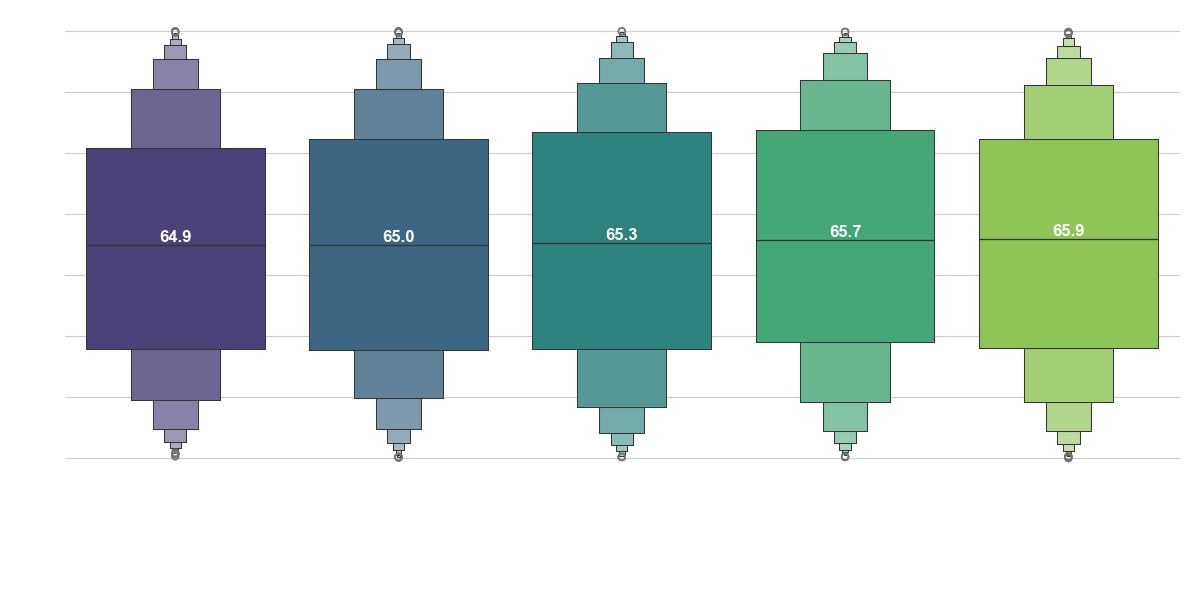

In [548]:
# Create a figure with specified size (width=12, height=6 inches)
plt.figure(figsize=(12, 6))

# Sort the purposes by median assignment score to create a meaningful order for the boxplot
purpose_order = stud_purpose.groupby('ai_usage_purpose')['assignment_scores_avg'].median().sort_values().index

# Create Boxplot showing distribution of assignment scores by AI usage purpose
ax = sns.boxenplot(x='ai_usage_purpose',
                 y='assignment_scores_avg', 
                 data=stud, 
                 palette='viridis',                # Use viridis color palette
                 order=purpose_order,              # Order categories by median score
                 # boxprops=dict(edgecolor='white'),  # Set box edge color to white
                 # whiskerprops=dict(color='white'),  # Set whisker color to white
                 # capprops=dict(color='white'),      # Set cap color to white
                 # medianprops=dict(color='white'),   # Set median line color to white
                 # flierprops=dict(markeredgecolor='white')  # Set outlier edge color to white
                )

# --- Styling the plot ---
#ax.set_title('Assignment Score by Usage Purpose', color='white', fontsize=14, pad=20)
ax.set_xlabel('Purpose of AI Use', color='white', fontsize=12)  # Set x-axis label
ax.set_ylabel('Average Assignment Score', color='white', fontsize=12)  # Set y-axis label
ax.tick_params(axis='x', colors='white', rotation=45)  # Rotate x-axis labels for better readability
ax.tick_params(axis='y', colors='white')  # Set y-axis tick color to white
for spine in ax.spines.values():
    spine.set_edgecolor('white')  # Set all plot borders to white

# --- Annotate Median Values on the Boxplot ---
# Calculate median values for each purpose category
medians = stud_purpose.groupby('ai_usage_purpose')['assignment_scores_avg'].median()
xtick_labels = [label.get_text() for label in ax.get_xticklabels()]

# Add text labels showing the median value for each category
for i, label in enumerate(xtick_labels):
    if label in medians.index:
        val = medians[label]
        ax.text(i, val, f'{val:.1f}',  # Format to 1 decimal place
                horizontalalignment='center', verticalalignment='bottom', 
                color='white', fontweight='bold', fontsize=12
               )

# Adjust layout and save the figure
plt.tight_layout()  # Adjust spacing to ensure everything fits
plt.savefig('boxplot_usage_purpose.png', transparent=True)  # Save with transparent background
plt.show()  # Display the plot

In [549]:
get_anova('ai_usage_purpose', 'assignment_scores_avg')

F-Statistic: 0.77
P-Value: 5.96e-01
Not Significant
--------------------


## D. Correlation of AI Metrics and Performance Metrics

In [550]:
# Define columns related to AI usage habits
ai_habit_cols = ['ai_usage_time_minutes', 'ai_dependency_score', 'ai_generated_content_percentage', 'ai_prompts_per_week', 'ai_ethics_score']

# Define columns related to student performance metrics
performance_cols = ['improvement_rate', 'assignment_scores_avg', 'final_score', 'concept_understanding_score', 'last_exam_score']

# Calculate correlation matrix for all columns (both AI habits and performance)
corr_matrix = stud[performance_cols + ai_habit_cols].corr()

# Extract only the correlations between AI habits (rows) and performance metrics (columns)
habit_performance_corr = corr_matrix.loc[performance_cols, ai_habit_cols]
habit_performance_corr  # Display the correlation matrix between AI habits and performance

,ai_usage_time_minutes,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score
improvement_rate,-0.016563,0.001123,0.022501,-0.014216,0.008076
assignment_scores_avg,0.009731,0.001983,-0.002759,-0.001409,0.012843
final_score,-0.001610,0.014077,-0.096552,-0.010148,0.013269
concept_understanding_score,0.006915,0.018077,0.021773,-0.003706,0.007420
last_exam_score,-0.015640,0.011436,0.017855,0.000871,0.006816


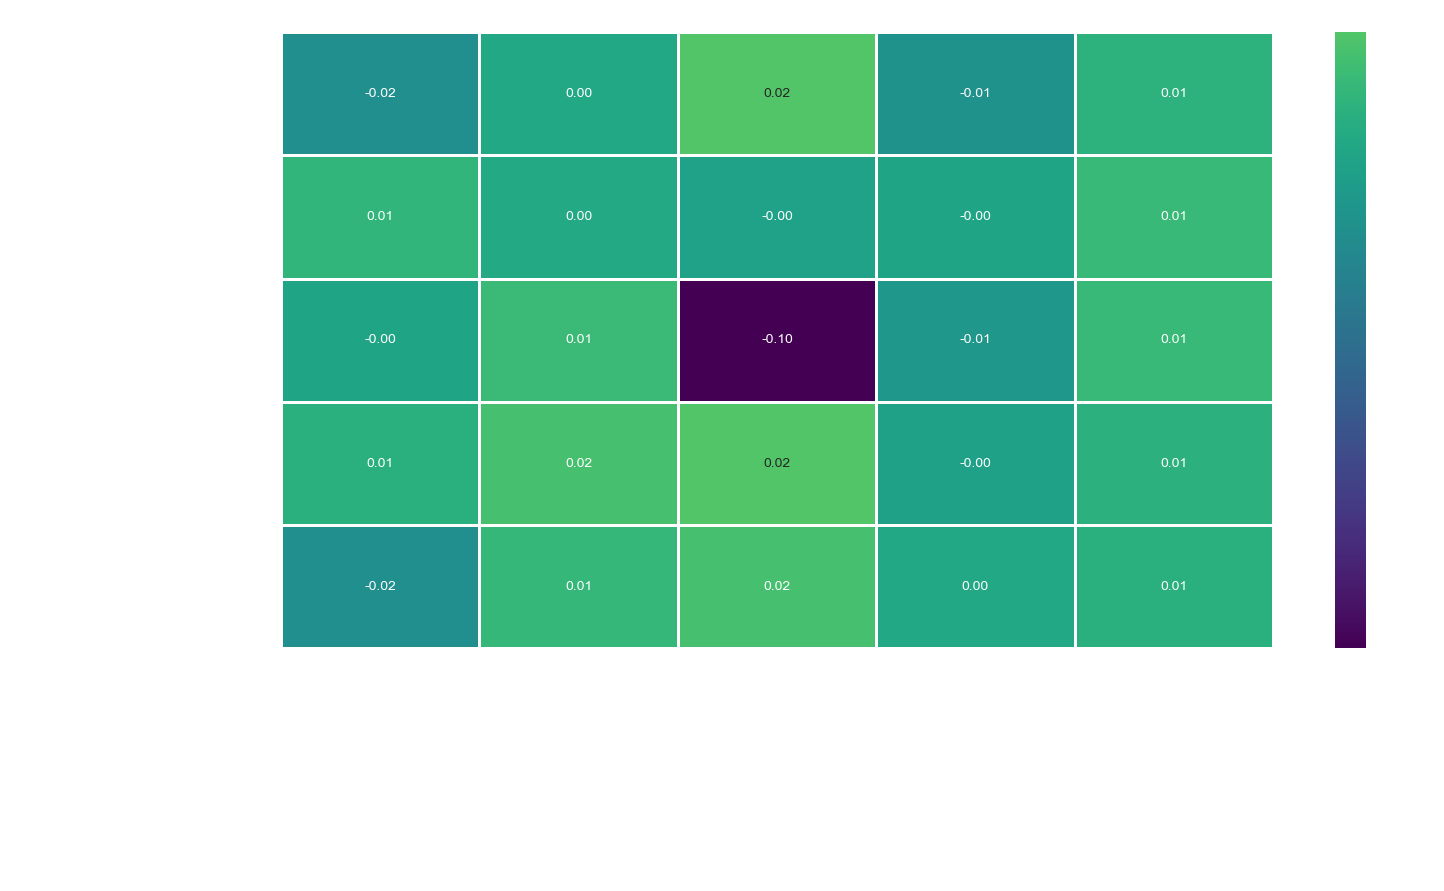

In [551]:
# Create a figure with specified size (width=16, height=8 inches)
plt.figure(figsize=(16,8))

# Generate a heatmap visualization of correlation matrix
sns.heatmap(habit_performance_corr, 
            annot=True,              # Show correlation values in each cell
            cmap='viridis',          # Use viridis color palette
            fmt='.2f',               # Format numbers to 2 decimal places
            center= -.015,           # Center the colormap at this value
            linewidths=1,            # Add lines between cells
            cbar_kws={'label': 'Correlation Coefficient'  # Label for the color bar
                     }
           )

# Add title to the plot with white color and specified font size
plt.title('Correlation: AI Habits vs Performance', color='white', fontsize=14)

# Format x-axis labels: white color, 45-degree rotation, right-aligned, size 14
plt.xticks(color='white', rotation=45, ha='right', fontsize=14)

# Format y-axis labels: white color, no rotation, size 14
plt.yticks(color='white', rotation=0, fontsize=14)

# Customize the colorbar appearance
cbar = plt.gcf().axes[-1]            # Get the colorbar object (last axes in figure)
cbar.tick_params(color='white', labelcolor='white')  # Make colorbar ticks and labels white
cbar.yaxis.label.set_color('white')  # Set colorbar label to white
cbar.yaxis.label.set_fontsize(14)    # Set colorbar label font size

# Save the figure with transparent background and tight layout
plt.savefig('Correlation_Heatmap.png', transparent=True, bbox_inches='tight')

# Display the plot
plt.show()

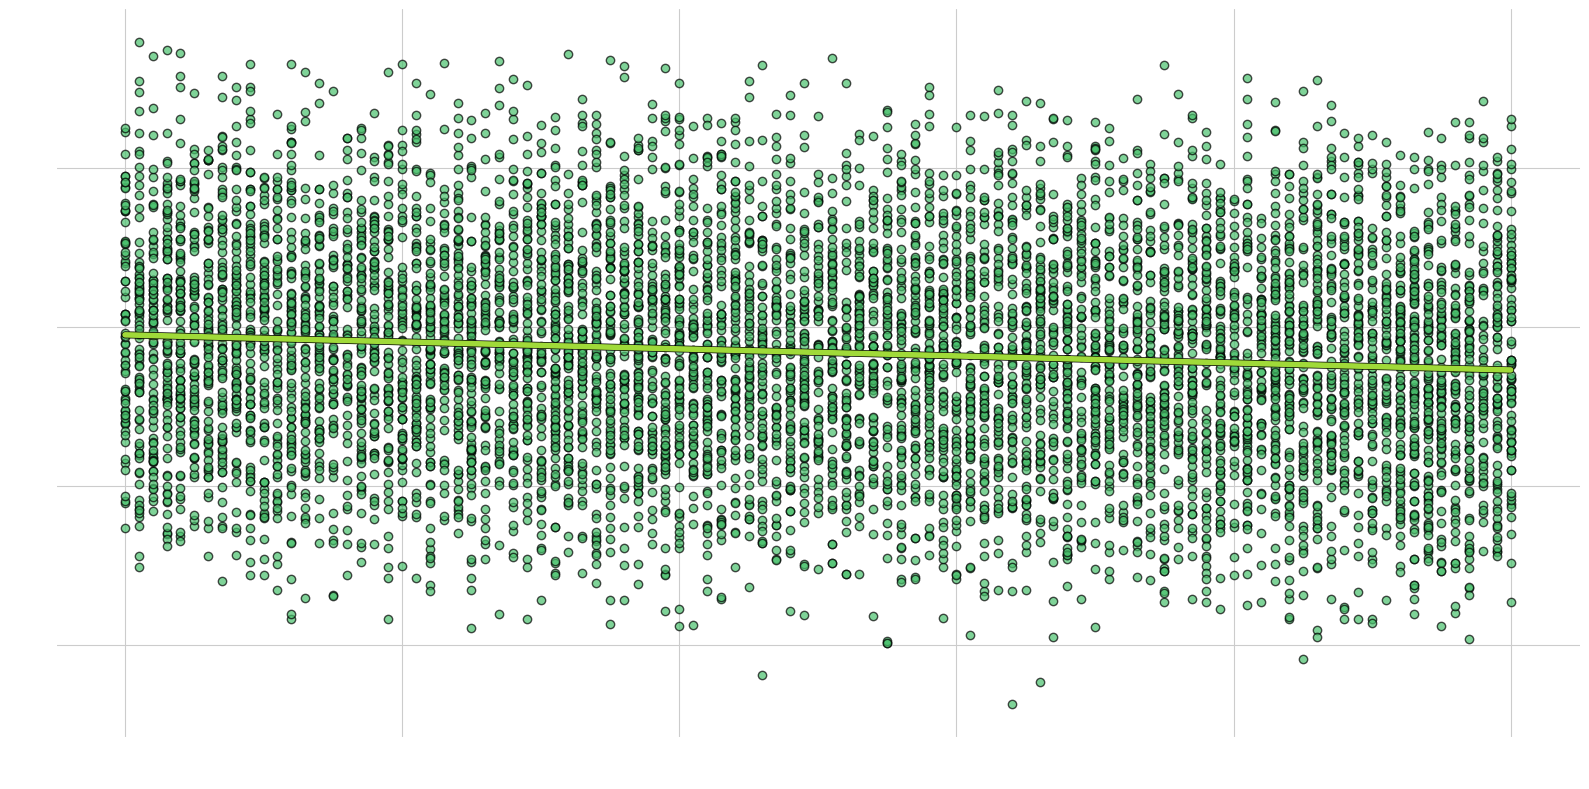

In [552]:
# Create the Scatter Plot with Trend Lines using lmplot
# aspect and height control the figure size
#plt.figure(figsize=(20, 12))

# Create a color palette from the viridis colormap with 20 colors
full_palette = sns.color_palette("viridis", 20)
# Select a specific color (index 14) for our scatter points
custom_palette = [full_palette[14]]

# --- 2. Create Plot with Outlined Lines ---
# Create a scatter plot with regression line using seaborn's lmplot
g = sns.lmplot(
    x='ai_generated_content_percentage',  # X-axis variable
    y='final_score',                      # Y-axis variable
    #hue='ai_generated_content_percentage', 
    data=stud,                            # DataFrame containing our data
    palette='viridis',                    # Color palette for the plot
    height=8,                             # Height of the figure in inches
    aspect=2,                             # Width to height ratio
    scatter_kws={'alpha': 0.7,            # Transparency of scatter points
                 'edgecolor': 'black',    # Border color of scatter points
                 'color' : custom_palette # Custom color for scatter points
                }, 
    line_kws={
        'color':full_palette[17],         # Color for regression line (index 17 from palette)
        'linewidth': 4,                   # Width of the regression line
        'path_effects': [
            pe.Stroke(linewidth=5, foreground='black'), # Add black outline to the line
            pe.Normal()                                 # Draw the normal colored line on top
        ]
    },
    legend=False                          # Don't show the legend
)

# --- 3. Styling ---
# Get the axes object from the plot
ax = g.ax
#ax.set_title('Impact of AI Usage Time on Final Score (Outlined Trends)', color='white', fontsize=16, pad=20)

# Set axis labels with white color for dark background
ax.set_xlabel('AI Generated Content (%)', color='white', fontsize=12)
ax.set_ylabel('Final Score', color='white', fontsize=12)

# Make tick labels white for better visibility on dark background
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

# Make all axis spines (borders) white
for spine in ax.spines.values():
    spine.set_edgecolor('white')

# Set transparent background for the plot area
ax.set_facecolor('none')
# Make the figure background transparent
g.fig.patch.set_alpha(0.0)

# Adjust layout to prevent clipping of labels
plt.tight_layout()
# Save the figure with transparent background
plt.savefig('scatter_trend_outlined.png', transparent=True, bbox_inches='tight')
# Display the plot
plt.show()

In [553]:
stud['content_quartiles'] = pd.qcut(stud['ai_generated_content_percentage'], 4)
get_anova('content_quartiles', 'final_score')

F-Statistic: 22.31
P-Value: 2.23e-14
Statistically Significant
--------------------


# Findings

AI use can affect a student's academic outcomes. 

Moderate use, focusing on homework, doubt solving, and exam prep, appears to be the best strategy for utilizing AI to help improve Academic gains.

Heavy use of AI, specifically as it relates to over reliance of AI generated content, showed a sharp decline in not only final scores, but also improvement rates.

Given the ubiquity of AI among students, AI regulations and policies should focus less on out right bans and focus more on regulating the ways in which AI can be used for academic work.

As the data shows, there are strategies of AI use that are conducive to positive academic growth, just as there are strategies which hinder academic growth.